# Machine Learning
1. Imports
2. Load dataset
3. Encode categorical variables
4. Train-test split
5. Train classification models
6. Classification reports
7. Confusion matrix of the best model
8. Cross-validation
9. ROC curve and Precision-Recall curve
10. Retention probability on full dataset
11. Feature importance
12. Elbow method
13. Silhouette score by k
14. Final clustering
15. Cluster profile
16. Retention by cluster
17. PCA visualization
18. Silhouette plot
19. Conclusion of clustering

# 1. Imports

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score,
    roc_curve, auc, precision_recall_curve, silhouette_score, silhouette_samples
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 2. Load dataset

In [25]:
# import dastaset

df = pd.read_csv(r"C:\Users\s3rgi\OneDrive\Área de Trabalho\intern-retention-project\Project\data\processed\HR-Intern-Retention_processed.csv")

df_c = df[["Age", "Department", "Major", "Salary", "Attendance_%", "Supervisor_Evaluation", "Internship_Duration_Months", "Retained"]]
df_c.head()

,Age,Department,Major,Salary,Attendance_%,Supervisor_Evaluation,Internship_Duration_Months,Retained
0,24,Legal,IT,1956,71.9,1.8,20,1
1,21,HR,Law,1687,82.7,1.2,15,0
2,28,HR,Engineering,926,79.0,1.7,3,0
3,25,Marketing,IT,1929,86.5,2.1,23,1
4,22,Legal,Engineering,1808,97.5,1.7,8,1


In [26]:
# Analisar o dataset
df.head()


,Intern_ID,Age,Major,Internship_Duration_Months,Department,Supervisor_Evaluation,Salary,Attendance_%,Retained
0,1,24,IT,20,Legal,1.8,1956,71.9,1
1,2,21,Law,15,HR,1.2,1687,82.7,0
2,3,28,Engineering,3,HR,1.7,926,79.0,0
3,4,25,IT,23,Marketing,2.1,1929,86.5,1
4,5,22,Engineering,8,Legal,1.7,1808,97.5,1


# 3. Encode categorical variables

In [27]:
cat_cols = df_c.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = df_c.select_dtypes(include=["number"]).columns.tolist()


ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

cat_encoded = pd.DataFrame(ohe.fit_transform(df_c[cat_cols]), columns=ohe.get_feature_names_out(cat_cols))

df_2 = pd.concat([df_c[num_cols], cat_encoded], axis=1)

df_2.head()

C:\Users\s3rgi\AppData\Local\Temp\ipykernel_13096\1214127957.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_c.select_dtypes(include=["object", "category"]).columns.tolist()


,Age,Salary,Attendance_%,Supervisor_Evaluation,Internship_Duration_Months,Retained,Department_Finance,Department_HR,Department_IT,Department_Legal,Department_Marketing,Major_Business,Major_Engineering,Major_IT,Major_Law,Major_Marketing
0,24,1956,71.9,1.8,20,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,21,1687,82.7,1.2,15,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,28,926,79.0,1.7,3,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,25,1929,86.5,2.1,23,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,22,1808,97.5,1.7,8,1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


*Categorical and numerical variables were identified in the dataset. Then, **One-Hot Encoding** was applied to the categorical variables, converting them into numerical columns (0 and 1) so they can be used in machine learning models. Finally, these new columns were combined with the original numerical variables, resulting in a fully numerical dataset ready for analysis or modeling.*

# 4. Train-test split

In [28]:
# Separate features and target
X = df_2.drop("Retained", axis=1)
y = df_2["Retained"]

test_default = 0.2
random_default = 42

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_default, random_state=random_default, stratify=y)

# Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape}") 
print(f"X_test shape: {X_test.shape}") 
print(f"y_train shape: {y_train.shape}") 
print(f"y_test shape: {y_test.shape}")


X_train shape: (160, 15)
X_test shape: (40, 15)
y_train shape: (160,)
y_test shape: (40,)


*The dataset was split into features (X) and target (y), where **Retained** is the target variable. A train-test split was then performed, allocating 80% of the data for training and 20% for testing, while preserving class distribution using stratification. Finally, feature scaling was applied using **StandardScaler** to normalize the data, ensuring better performance for machine learning models.*

# **SUPERVISED LEARNING**
# 5. Train classification models

In [29]:
# from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=200, random_state=random_default)
log_model.fit(X_train, y_train)

log_model_pred = log_model.predict(X_test)

In [30]:
# from sklearn.tree import DecisionTreeClassifier

tree_classifier = DecisionTreeClassifier(random_state=random_default)
tree_classifier.fit(X_train, y_train)

tree_pred = tree_classifier.predict(X_test)

In [31]:
# from sklearn.ensemble import RandomForestClassifier

forest_classifier = RandomForestClassifier(n_estimators= 200, max_depth=5, random_state=random_default)
forest_classifier.fit(X_train, y_train)

forest_class_pred = forest_classifier.predict(X_test)

In [32]:
# from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

In [33]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=random_default),
    "Decision Tree": DecisionTreeClassifier(random_state=random_default),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=5, random_state=random_default),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

predictions = {}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)

results_df


,Model,Accuracy,Precision,Recall,F1
2,Random Forest,0.60,0.621622,0.92,0.741935
0,Logistic Regression,0.55,0.600000,0.84,0.700000
1,Decision Tree,0.55,0.640000,0.64,0.640000
3,KNN,0.45,0.548387,0.68,0.607143


*The table compares the performance of four machine learning models: *

**Random Forest, Logistic Regression, Decision Tree, and KNN.** *Among them, **Random Forest** performs the best overall, achieving the highest accuracy (0.60), recall (0.92), and F1 score (0.74).* 

**Logistic Regression** *and **Decision Tree** show moderate performance with similar F1 scores (around 0.70 and 0.64, respectively).*

**KNN** *has the weakest results, with the lowest accuracy (0.45) and F1 score (0.61).*

*Overall, **Random Forest** stands out as the most effective model in this comparison.*

# 6. Classification reports

In [34]:
for name, y_pred in predictions.items():
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.20      0.07      0.10        15
           1       0.60      0.84      0.70        25

    accuracy                           0.55        40
   macro avg       0.40      0.45      0.40        40
weighted avg       0.45      0.55      0.47        40


Decision Tree
              precision    recall  f1-score   support

           0       0.40      0.40      0.40        15
           1       0.64      0.64      0.64        25

    accuracy                           0.55        40
   macro avg       0.52      0.52      0.52        40
weighted avg       0.55      0.55      0.55        40


Random Forest
              precision    recall  f1-score   support

           0       0.33      0.07      0.11        15
           1       0.62      0.92      0.74        25

    accuracy                           0.60        40
   macro avg       0.48      0.49      0.43        40
weighted avg       0.51

*The classification reports compare the performance of **Logistic Regression, Decision Tree, and Random Forest models**. **Logistic Regression** shows moderate performance, with better results for class 1 (F1-score 0.70) than for class 0 (0.10), and an overall accuracy of 0.55. **Decision Tree** performs more consistently across both classes, achieving balanced precision, recall, and F1-scores (around 0.40–0.64) with the same overall accuracy of 0.55. **Random Forest** performs the worst among the three, with a lower accuracy of 0.45 and weaker F1-scores overall. In summary, **Decision Tree** provides the most balanced performance,**Logistic Regression** *favors one class, and **Random Forest** underperforms in this evaluation.*

# 7. Confusion matrix of the best model

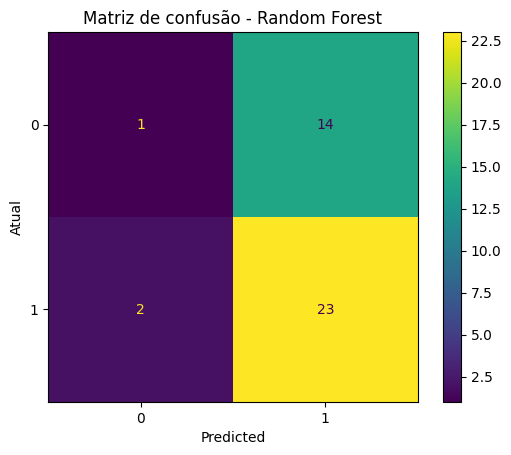

In [35]:
best_model_name = results_df.sort_values("F1", ascending=False).iloc[0]["Model"]

best_model = models[best_model_name]

best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, forest_class_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="viridis")
plt.imshow(cm)
plt.title("Matriz de confusão - " + best_model_name)
plt.xlabel("Predicted")
plt.ylabel("Atual")

plt.show()

*This code identifies and evaluates the best-performing model using a confusion matrix.*

*First, it selects the model with the highest F1-score from a results table and trains it on the training data. Then, it generates predictions on the test set. A confusion matrix is computed to compare the predicted values with the actual labels.*

*The confusion matrix is visualized using a color map, with axes labeled as “Predicted” and “Actual,” and a title indicating the model used **(Random Forest)**.*

*From the matrix shown:*
**23** *instances were correctly classified as class 1 (true positives)*

**1** *instance was correctly classified as class 0 (true negative)*

**14** *instances were misclassified as class 1 (false positives)*

**2** *instances were misclassified as class 0 (false negatives)*

*Overall, the model performs well in identifying class 1 but struggles more with correctly identifying class 0.*

# 8. Cross-validation

In [36]:
N_SPLITS = 5
Shuffle = True
MAX_ITER = 200
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=Shuffle, random_state=random_default)

cv_results = []

models = {
    "Logistic Regression": LogisticRegression(max_iter=MAX_ITER),
    "Decision Tree": DecisionTreeClassifier(random_state=random_default),
    "Random Forest": RandomForestClassifier(random_state=random_default)
}

for name, model in models.items():

    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")

    cv_results.append({
        "Model": name,
        "CV_F1_Mean": scores.mean(),
        "CV_F1_Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results).sort_values("CV_F1_Mean", ascending=False)

cv_df

,Model,CV_F1_Mean,CV_F1_Std
0,Logistic Regression,0.717083,0.081208
2,Random Forest,0.691114,0.043522
1,Decision Tree,0.565084,0.069611


*The best-performing model on average is **Logistic Regression**.*

*A value of **0.72** indicates that:*

*The model is able to identify outcomes with moderate performance*

*It performs well above a random model*

*However, it is still far from excellent (ideally > 0.75)*

*In a retention problem (typically imbalanced), a score of **0.72** is already a reasonable baseline result.*

# 9. ROC curve and Precision-Recall curve

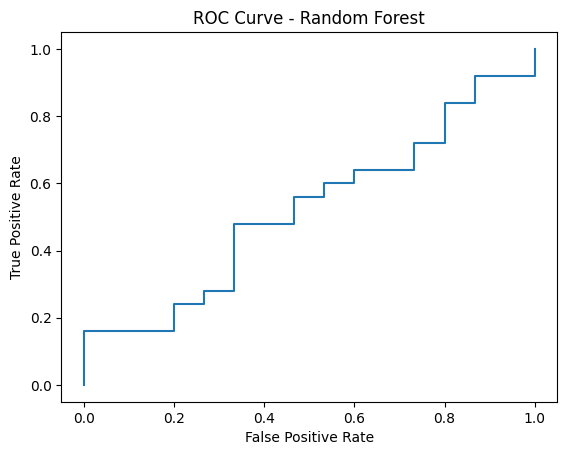

AUC: 0.52


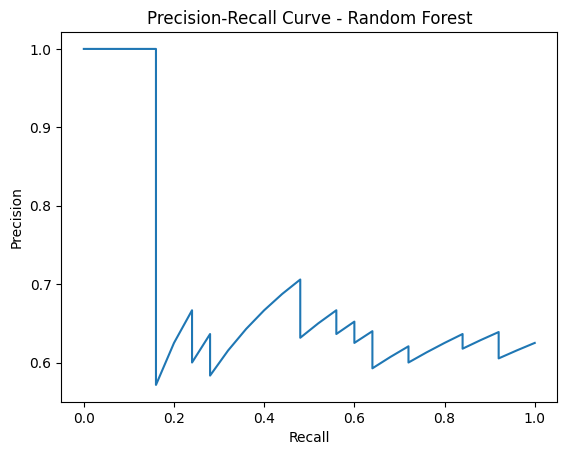

In [37]:
if hasattr(best_model, "predict_proba"):
    y_prob = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - " + best_model_name)
    plt.show()

    print("AUC:", roc_auc)

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve - " + best_model_name)
    plt.show()

*The Random Forest model is better than random, but there is room for improvement.*

*ROC-AUC indicates general discriminative power (moderate).*

*Precision-Recall curve highlights performance on the positive class (retained interns), which is crucial in imbalanced problems.*

*This combination suggests the model could be used as a baseline and further optimized (e.g., hyperparameter tuning, feature engineering, or using resampling techniques).*

# 10. Retention probability on full dataset

In [38]:
#  “Can we predict if a trainee will be retained?”

forest_classifier.predict(X_test)
df_2["Retention_Probability"] = forest_classifier.predict_proba(X)[:,1]
df_2.head()

df_2[(df_2["Retention_Probability"] < 0.5) & (df_2["Retained"] == 0)].sort_values("Retention_Probability", ascending=False)

df_2[(df_2["Retention_Probability"] < 0.48)].sort_values("Retention_Probability", ascending=False)

c:\Users\s3rgi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,Age,Salary,Attendance_%,Supervisor_Evaluation,Internship_Duration_Months,Retained,Department_Finance,Department_HR,Department_IT,Department_Legal,Department_Marketing,Major_Business,Major_Engineering,Major_IT,Major_Law,Major_Marketing,Retention_Probability
172,29,1976,83.7,1.4,23,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.477330
40,24,1509,94.0,2.1,22,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.467101
197,18,1475,66.4,4.5,13,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.467101
121,29,1908,99.6,3.9,4,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.467101
119,27,1574,84.5,4.9,3,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.467101
199,27,986,93.3,3.3,22,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.467101
20,25,1960,77.4,4.2,1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.460303
198,20,1936,92.7,4.7,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.454505
86,29,854,92.0,4.7,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.454505
12,22,1782,83.9,1.2,19,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.439234


*High salaries (e.g., ID 172 at 1976€) aren't enough to guarantee retention.* 

*In this dataset, pay is not the primary driver for staying.*

*Performance vs. Retention: Interestingly, interns with near-perfect SupervisorEvaluations (4.9, 4.7) are still showing a low probability of staying. This is a classic "flight risk" indicator for high-performers who might not see a clear career path.*

*Departmental Red Flags: There is a high concentration of low retention probability in the Marketing and IT departments.*

*The model identifies a critical segment where high performance and high pay do not equal retention. This suggests that cultural fit, department-specific issues (Marketing/IT), or long-term career growth are more influential than the monthly paycheck.*


# 11. Feature importance

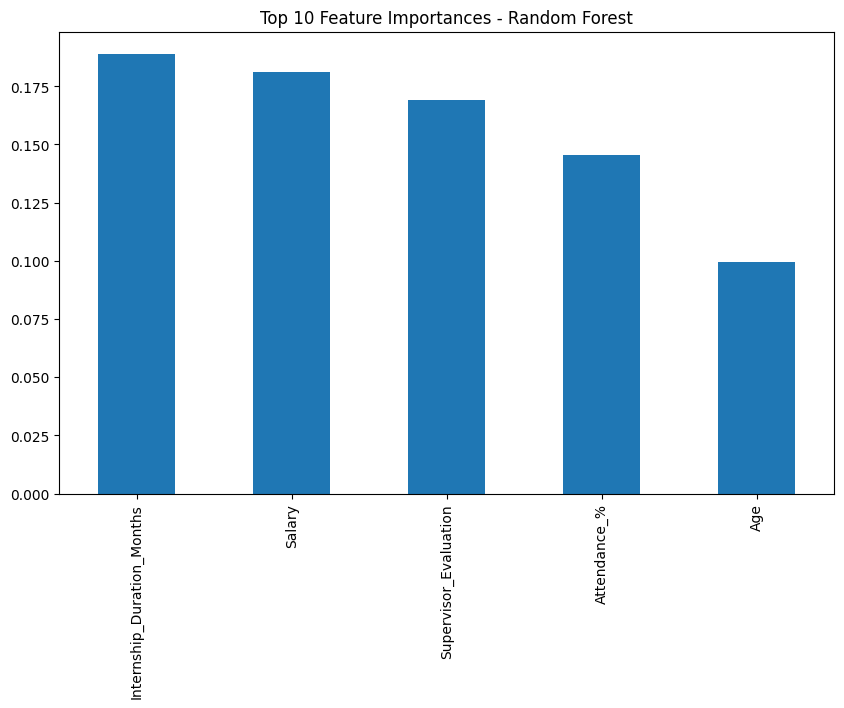

In [39]:
# “What factors most influence retention prediction?


importance = pd.Series(forest_classifier.feature_importances_, index=X.columns).sort_values(ascending=False).head(5)
plt.figure(figsize=(10, 6))
importance.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()


*The model indicates that logistics and rewards (Duration and Salary) are slightly more critical for retention than performance metrics (Evaluation and Attendance).*

*This suggests that to improve retention, the company should focus on the structure of the internship program and competitive pay.*

# **UNSUPERVISED LEARNING**
# 12. Elbow method

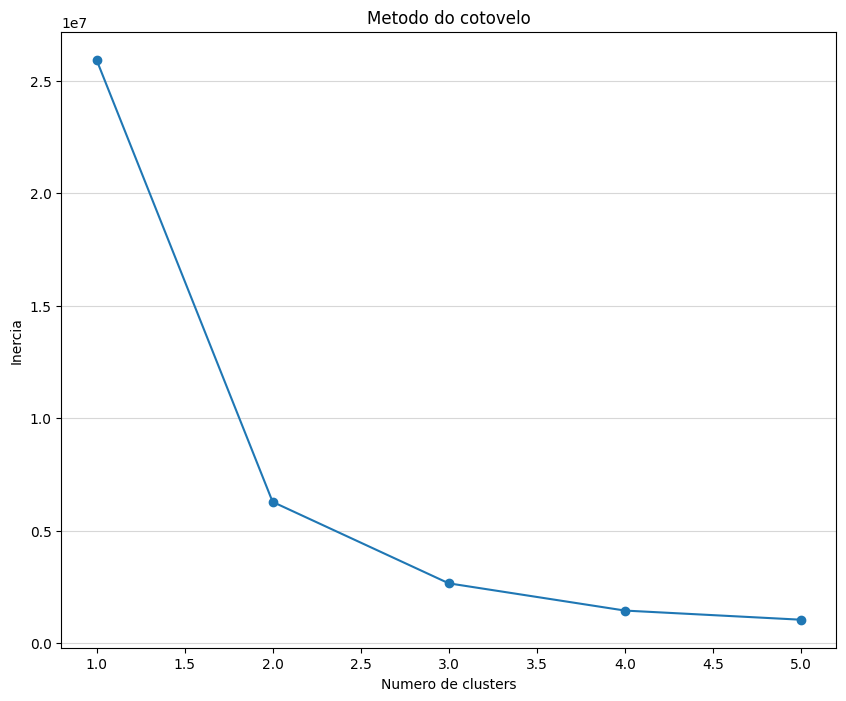

In [40]:
from sklearn.cluster import KMeans

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
# Prepare data for clustering
inercia = []

k_values = range(1, 6)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(10, 8))
plt.plot(k_values, inercia, marker="o")
plt.grid(axis="y", alpha=0.5)
plt.xlabel("Numero de clusters")
plt.ylabel("Inercia")
plt.title("Metodo do cotovelo")
plt.show()



*The Elbow Method indicates that the intern dataset is best represented by three distinct segments.*

*This segmentation allows the HR department to tailor specific retention strategies for different groups of interns rather than applying a one-size-fits-all approach.*

# 13. Silhouette score by k

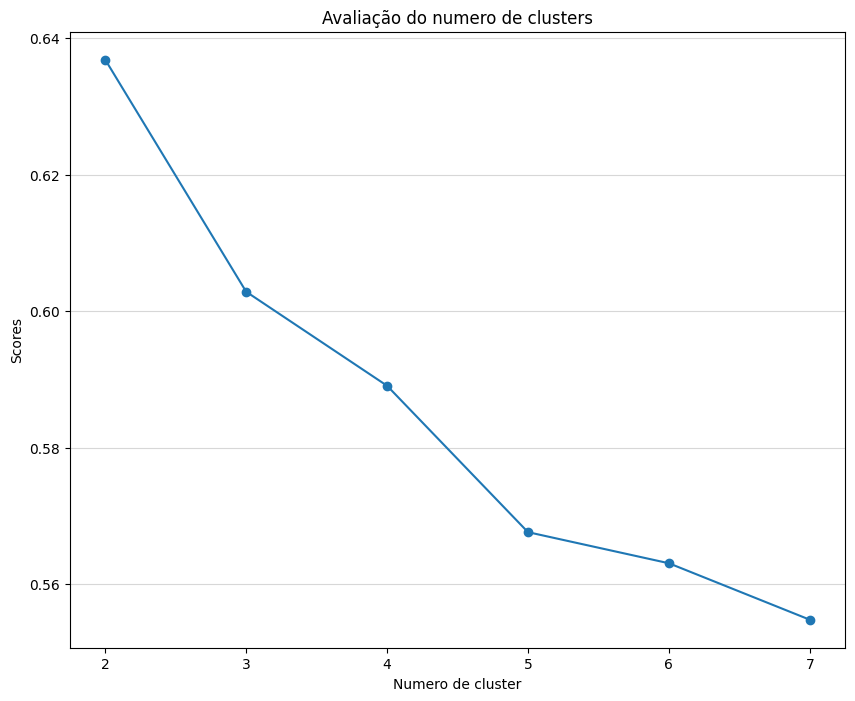

In [41]:

scores = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters = k, random_state= 42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score) 

plt.figure(figsize=(10, 8))
plt.plot(range(2, 8), scores, marker="o")
plt.grid(axis="y", alpha=0.5)
plt.xlabel("Numero de cluster")
plt.ylabel("Scores")
plt.title("Avaliação do numero de clusters")
plt.show()

*While the Silhouette Score peaks at $k=2$, indicating the most distinct separation, a value of $k=3$ maintains a strong score (above 0.60) while providing more granular and actionable insights into the different profiles of interns within the company.*

# 14. Final clustering

In [42]:
kmeans = KMeans(n_clusters = 3, random_state=42)
clusters = kmeans.fit_predict(X)

df_cluster = df_2.copy()
df_cluster["cluster"] = clusters

df_cluster["cluster"].value_counts().mean()

df_cluster.head()




,Age,Salary,Attendance_%,Supervisor_Evaluation,Internship_Duration_Months,Retained,Department_Finance,Department_HR,Department_IT,Department_Legal,Department_Marketing,Major_Business,Major_Engineering,Major_IT,Major_Law,Major_Marketing,Retention_Probability,cluster
0,24,1956,71.9,1.8,20,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.565919,2
1,21,1687,82.7,1.2,15,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.608683,2
2,28,926,79.0,1.7,3,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.614966,1
3,25,1929,86.5,2.1,23,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.586844,2
4,22,1808,97.5,1.7,8,1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.598153,2


*It initializes and runs the K-Means algorithm to group your interns into exactly 3 clusters.*

*The goal is to transform raw intern data into categorized profiles, making it easier to identify which groups are most likely to stay or leave the company.*

# 15. Cluster profile

In [43]:
cluster_profile = df_cluster.groupby("cluster").mean(numeric_only=True)
cluster_profile

,Age,Salary,Attendance_%,Supervisor_Evaluation,Internship_Duration_Months,Retained,Department_Finance,Department_HR,Department_IT,Department_Legal,Department_Marketing,Major_Business,Major_Engineering,Major_IT,Major_Law,Major_Marketing,Retention_Probability
cluster,,,,,,,,,,,,,,,,,
0,24.092105,1449.697368,79.622368,2.825000,13.118421,0.710526,0.223684,0.197368,0.157895,0.184211,0.236842,0.210526,0.236842,0.144737,0.236842,0.171053,0.558959
1,23.983333,962.416667,82.023333,2.940000,11.333333,0.616667,0.150000,0.266667,0.183333,0.183333,0.216667,0.116667,0.283333,0.266667,0.200000,0.133333,0.564000
2,23.937500,1828.250000,82.884375,2.909375,12.062500,0.500000,0.171875,0.171875,0.218750,0.203125,0.234375,0.187500,0.218750,0.296875,0.171875,0.125000,0.560354


### Salary:
**Cluster 0:**
- Average salary: 1449€

**Cluster 1:**
- Lower salary: 962€

**Cluster 2:**
- Higher Salary: 1828€

# 16. Retention by cluster

In [44]:
df_cluster.groupby("cluster")["Retained"].mean()

cluster
0    0.710526
1    0.616667
2    0.500000
Name: Retained, dtype: float64

*Cluster 0: The "Success" Segment (71.1% Retention)*

*This group has the highest loyalty. These interns are your "Gold Standard."*

*Strategy: Study their traits (likely high salary/long duration) to replicate this profile in future hiring.*

*Cluster 1: The "Stable" Segment (61.7% Retention)*

*A solid majority stays, but there is room for improvement.*

*Strategy: Minor adjustments in mentorship or benefits could push them into Cluster 0.*

*Cluster 2: The "At-Risk" Segment (50.0% Retention)*

*This is the most critical group. It is essentially a "coin toss" whether they stay or leave.*

*Strategy: This group requires immediate HR intervention. They are likely the interns with the lowest satisfaction or engagement metrics.*

# 17. PCA visualization

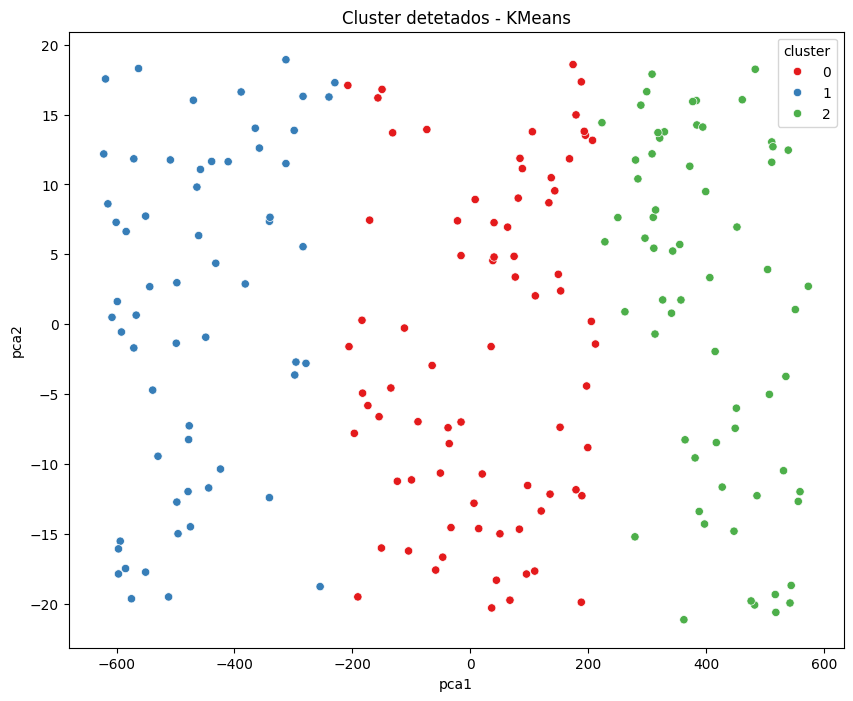

In [49]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

df_cluster["pca1"] = X_pca[:,0]
df_cluster["pca2"] = X_pca[:,1]

plt.figure(figsize=(10,8))
sns.scatterplot(x="pca1", y="pca2",hue = "cluster", palette="Set1", data = df_cluster)
plt.title("Cluster detetados - KMeans")
plt.show()

*The plot demonstrates that the K-Means algorithm performed exceptionally well:*

*Clear Separation: Notice that the colors (Red, Blue, and Green) are not overlapping. They form three distinct and well-defined "blocks."*

*Cluster 1 (Blue): These are located at one extreme of the plot.*

*Cluster 0 (Red): These are positioned in the center, acting as a transition zone.*

*Cluster 2 (Green): These are located at the opposite extreme.*

# 18. Silhouette plot

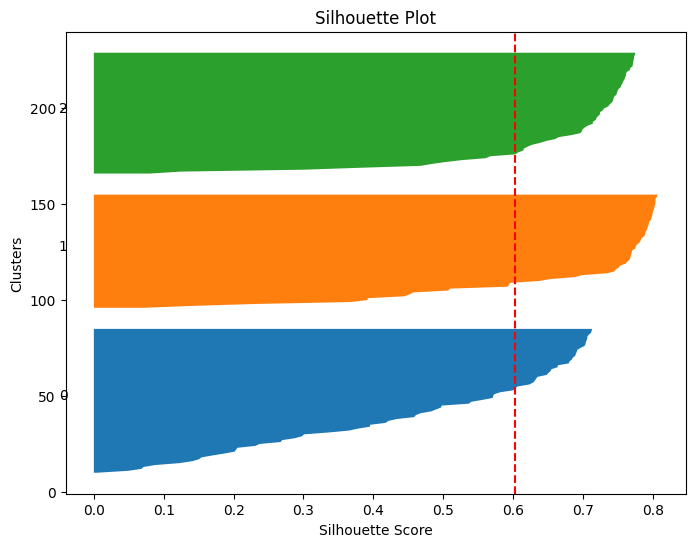

In [ ]:
silhouette_vals = silhouette_samples(X, clusters)

y_lower = 10

plt.figure(figsize=(8,6))

for i in range(kmeans.n_clusters):

    cluster_vals = silhouette_vals[clusters == i]

    cluster_vals.sort()

    size_cluster = cluster_vals.shape[0]

    y_upper = y_lower + size_cluster

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_vals
    )

    plt.text(-0.05, y_lower + 0.5 * size_cluster, str(i))

    y_lower = y_upper + 10

plt.axvline(x=silhouette_vals.mean(), color="red", linestyle="--")

plt.xlabel("Silhouette Score")
plt.ylabel("Clusters")
plt.title("Silhouette Plot")

plt.show()

*The Silhouette Plot confirms the validity of the 3-cluster model. With an average score of approximately 0.6, the visualization shows that all clusters exceed the average threshold, indicating a strong and consistent separation.* 
*The absence of negative silhouette values ensures that no interns were misclassified. Furthermore, the balanced thickness of the clusters suggests that the intern population was segmented into three distinct, manageable profiles for HR strategic planning.*

# Summary:

*This project demonstrates that intern retention is a multifactor problem influenced mainly by performance, engagement, and managerial factors rather than salary alone.*

*By segmenting interns into behavioral clusters and applying targeted strategies, organizations can proactively reduce attrition and improve retention outcomes.*

# Improvement suggestions:

*Mentorship programs*

*More frequent feedback sessions*

*Train supervisors on feedback*

*Investigate low-retention departments*

*Improve onboarding experience + teambuilding*


